In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot(time, series, x, y, name):
    if time is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(time, series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()

In [3]:
def to_price(sqrtPriceX96, decimals0 = 18, decimals1 = 18):
    return ((sqrtPriceX96 / (2 ** 96)) ** 2)*10**(decimals0-decimals1)

In [4]:
import json

with open("data_from_David/nect_honey.json", "r") as file:
    data_nect = json.load(file)

display(data_nect)

[{'id': '0x56a5ac11ba0f2c6b887d3e3aa154e3dd9859eac2-235000',
  'liquidity': '0',
  'sqrtPriceX96': '79228162514264337593543950336',
  'blockNumber': '235000',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 0,
  'timestamp': '1737826547',
  'unlocked': True,
  'token0BalanceKodiak': '0',
  'token0BalancePool': '0',
  'token1BalanceKodiak': '0',
  'token1BalancePool': '0',
  'totalSupply': '0',
  'managerToken1BalancerManager': '0',
  'managerToken0BalancerManager': '0',
  'upperTick': 1400,
  'lowerTick': -1400,
  'positionID': '0x7cb6c39709f22acb6fecedd3a66b81dc2a740cc7adc991f468a301620ae5c65e'},
 {'id': '0x56a5ac11ba0f2c6b887d3e3aa154e3dd9859eac2-235100',
  'liquidity': '0',
  'sqrtPriceX96': '79228162514264337593543950336',
  'blockNumber': '235100',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X

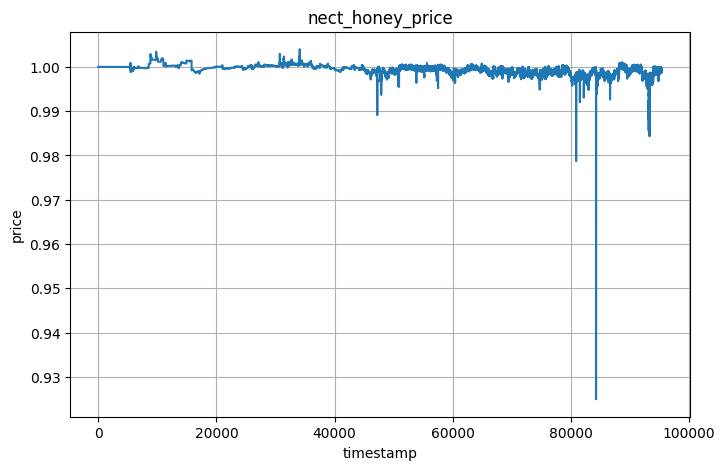

In [5]:
sqrt_prices_nect = [item['sqrtPriceX96'] for item in data_nect]
sqrt_prices_nect = np.array(sqrt_prices_nect).astype(float)

nect_honey_price = to_price(sqrt_prices_nect)

plot(
    None,
    nect_honey_price,
    'timestamp',
    'price',
    'nect_honey_price'
)

In [6]:
with open("data_from_David/weth_honey.json", "r") as file:
    data_weth = json.load(file)

display(data_weth)

[{'id': '0x9eb897d400f245e151dafd4c81176397d7798c9c-264400',
  'liquidity': '0',
  'sqrtPriceX96': '4571952403387162006772020670989',
  'blockNumber': '264400',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 81111,
  'timestamp': '1737881717',
  'unlocked': True,
  'token0BalanceKodiak': '0',
  'token0BalancePool': '0',
  'token1BalanceKodiak': '0',
  'token1BalancePool': '0',
  'totalSupply': '0',
  'managerToken1BalancerManager': '0',
  'managerToken0BalancerManager': '0',
  'upperTick': 887220,
  'lowerTick': -887220,
  'positionID': '0x79553f70a46987b002450902a3eb3d3cc89389630d473eabed42228ac1455024'},
 {'id': '0x9eb897d400f245e151dafd4c81176397d7798c9c-264500',
  'liquidity': '0',
  'sqrtPriceX96': '4571952403387162006772020670989',
  'blockNumber': '264500',
  'feeGrowthGlobal0X128': '0',
  'feeGr

105.69705876658082
2792.967051770128
0.5000000005535632
1738819938.0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20376\1195294071.py:13: RuntimeWarning: invalid value encountered in divide
  weth_frac = WETHIslandBalance*weth_honey_price/(WETHIslandBalance*weth_honey_price + HONEYIslandBalance)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20376\1195294071.py:14: RuntimeWarning: invalid value encountered in divide
  nav = (WETHIslandBalance*weth_honey_price + HONEYIslandBalance)/total_supply_weth_honey


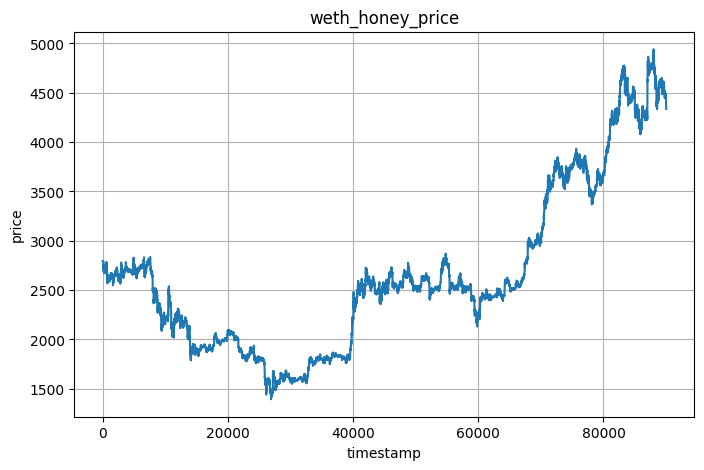

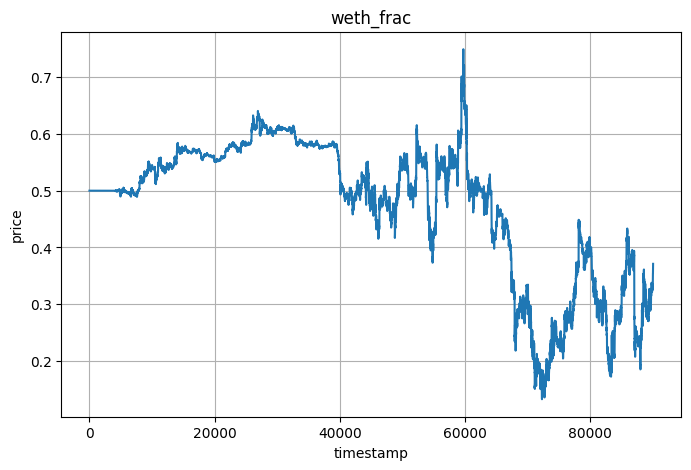

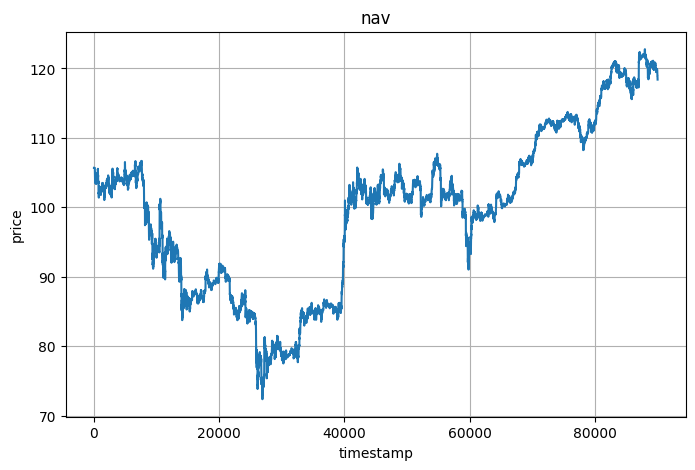

In [7]:
sqrt_prices_weth = [item['sqrtPriceX96'] for item in data_weth]
sqrt_prices_weth = np.array(sqrt_prices_weth).astype(float)
total_supply_weth_honey = [item['totalSupply'] for item in data_weth]
token1IslandBalance = [item['token1BalanceKodiak'] for item in data_weth]
token0IslandBalance = [item['token0BalanceKodiak'] for item in data_weth]
timestamp = [item['timestamp'] for item in data_weth]
timestamp = np.array(timestamp).astype(float)

total_supply_weth_honey = np.array(total_supply_weth_honey).astype(float)/10**18
weth_honey_price = to_price(sqrt_prices_weth)
WETHIslandBalance = np.array(token0IslandBalance).astype(float)/10**18
HONEYIslandBalance = np.array(token1IslandBalance).astype(float)/10**18
weth_frac = WETHIslandBalance*weth_honey_price/(WETHIslandBalance*weth_honey_price + HONEYIslandBalance)
nav = (WETHIslandBalance*weth_honey_price + HONEYIslandBalance)/total_supply_weth_honey

nect_honey_price = nect_honey_price[4500:]
weth_honey_price = weth_honey_price[5000:]
weth_frac = weth_frac[5000:]
nav = nav[5000:]
timestamp = timestamp[5000:]

print(nav[0])
print(weth_honey_price[0])
print(weth_frac[0])
print(timestamp[0])

plot(
    None,
    weth_honey_price,
    'timestamp',
    'price',
    'weth_honey_price'
)

plot(
    None,
    weth_frac,
    'timestamp',
    'price',
    'weth_frac'
)

plot(
    None,
    nav,
    'timestamp',
    'price',
    'nav'
)

In [8]:
nav = nav
weth_honey_price = weth_honey_price
weth_frac = weth_frac
nect_honey_price = nect_honey_price[len(nect_honey_price) - len(nav):]

print(len(nect_honey_price))
print(len(nav))
print(len(weth_honey_price))
print(len(weth_frac))

90026
90026
90026
90026


In [9]:
N = int(0.8*len(nav))

df_train = pd.DataFrame({
    'timestamp': timestamp[:N],
    'nav': nav[:N],
    'weth_frac': weth_frac[:N],
    'weth_price': weth_honey_price[:N],
    'nect_price': nect_honey_price[:N]
})

df_test = pd.DataFrame({
    'timestamp': timestamp[N:],
    'nav': nav[N:],
    'weth_frac': weth_frac[N:],
    'weth_price': weth_honey_price[N:],
    'nect_price': nect_honey_price[N:]
})

display(df_train)
display(df_test)

df_train.to_csv('weth_train_data_expanded.csv', index=False)
df_test.to_csv('weth_test_data_expanded.csv', index=False)

,timestamp,nav,weth_frac,weth_price,nect_price
0,1.738820e+09,105.697059,0.500000,2792.967052,1.000000
1,1.738820e+09,105.697059,0.500000,2792.967052,1.000000
2,1.738820e+09,105.697059,0.500000,2792.967052,1.000000
3,1.738821e+09,105.697059,0.500000,2792.967052,1.000000
4,1.738821e+09,105.697059,0.500000,2792.967052,1.000000
...,...,...,...,...,...
72015,1.752979e+09,111.693135,0.172600,3614.785543,0.998749
72016,1.752979e+09,111.693135,0.172600,3614.785543,0.998749
72017,1.752979e+09,111.693135,0.172600,3614.785543,0.998750
72018,1.752980e+09,111.693664,0.172567,3614.884676,0.998750


,timestamp,nav,weth_frac,weth_price,nect_price
0,1.752980e+09,111.693664,0.172567,3614.884676,0.998645
1,1.752980e+09,111.693664,0.172567,3614.884676,0.998645
2,1.752980e+09,111.693664,0.172567,3614.884676,0.998645
3,1.752981e+09,111.698168,0.172279,3615.728749,0.998645
4,1.752981e+09,111.699467,0.172196,3615.972668,0.998645
...,...,...,...,...,...
18001,1.756458e+09,118.591370,0.365353,4355.274268,0.998730
18002,1.756458e+09,118.498807,0.368114,4346.003610,0.998731
18003,1.756458e+09,118.462583,0.369189,4342.397922,0.998773
18004,1.756458e+09,118.392808,0.371250,4335.487144,0.998773
